2025-06-20 19:17:34.571891: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-06-20 19:17:36.528165: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-06-20 19:17:36.528272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-06-20 19:17:36.657544: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-06-20 19:17:37.154945: I tensorflow/core/platform/cpu_feature_guar

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
data ['LA_RSPV_CAF_150115', 'Simulation_01_200428_001_001', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_210119_001_001', 'Simulation_01_210205_001_003', 'LA_PLAW_140612', 'Simulation_01_190717_001_004', 'Simulation_01_201223_001_002', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_200428_001

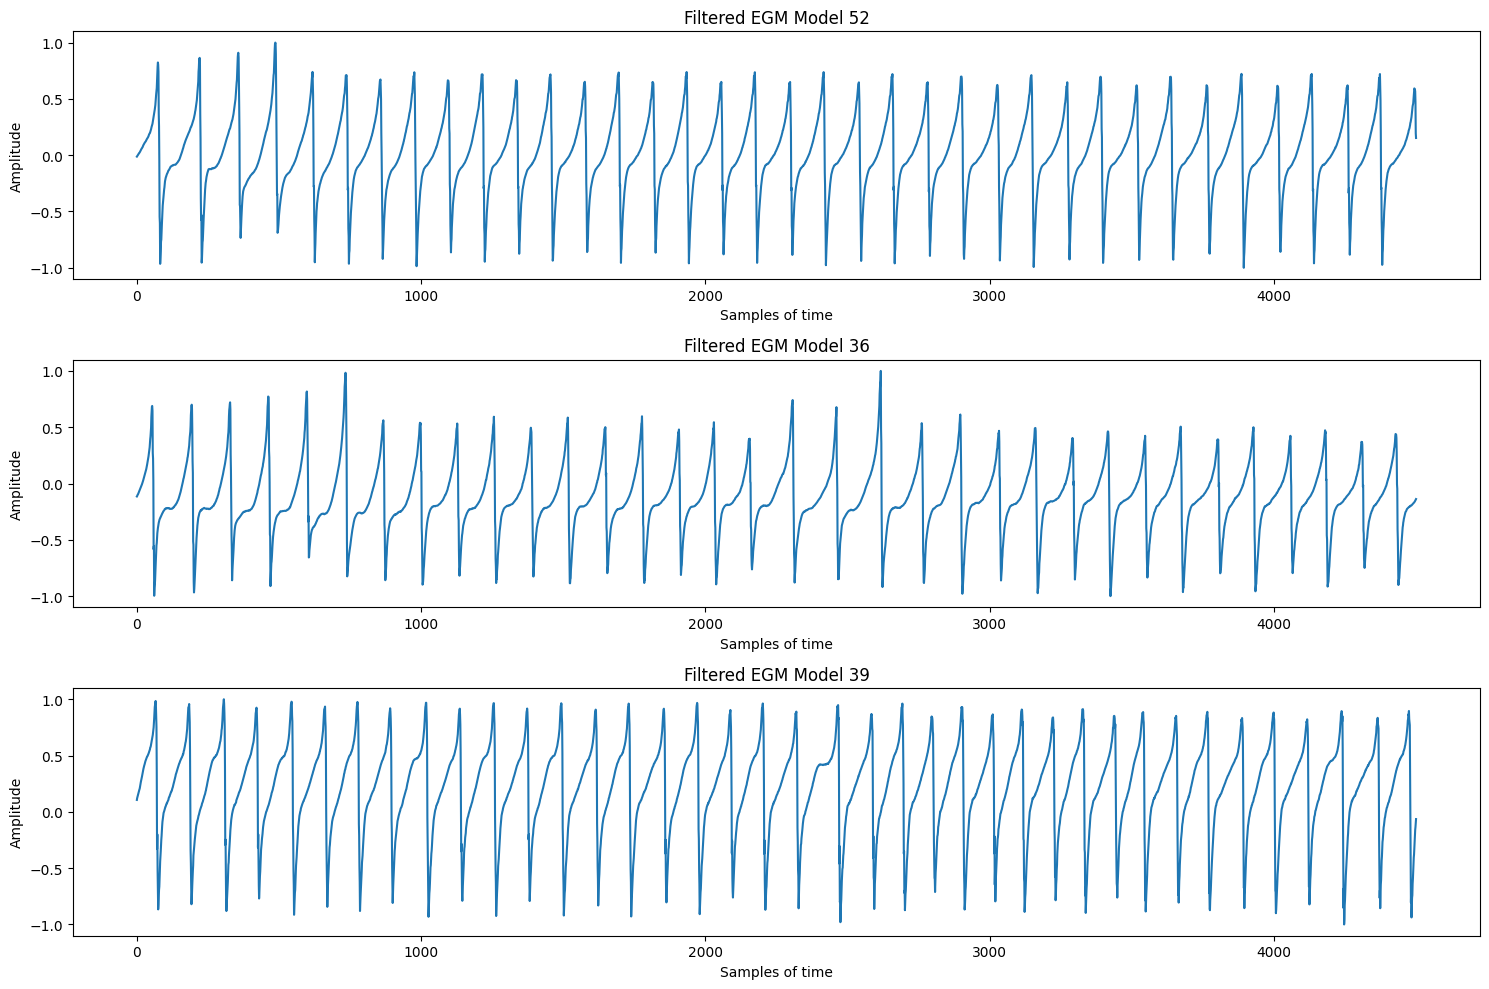

10
Transfer matrices LOADED - var: **transfer_matrices** 
BSPS Models LOADED - var: **bsps_all_models** 
BSPS 64 Models LOADED - var: **bsps_64_all_models** 
550
(3610, 2499)
(3610, 2499)
(64, 2499)
(3970, 2499)
(64, 2499)
(64, 2001)
550
BSPS 64 Models LOADED - var: **bsps_64_all_models** 


In [1]:
import os
os.environ["XLA_FLAGS"] = "--xla_gpu_cuda_data_dir=/home/alumnos/mburgosc/cuda-fake"

import tensorflow as tf

import tensorflow as tf 
import numpy as np
gpus = tf.config.list_physical_devices("GPU")

print(gpus)

import import_data

egms_all_models = import_data.egms_all_models
egms_values = import_data.egms_values
egms_filtered_norm = import_data.egms_filtered_norm
bsps_all_models = import_data.bsps_all_models
bsps_64_all_models = import_data.bsps_64_all_models
transfer_matrices = import_data.transfer_matrices
models_names = import_data.models_names
bsps_64_all_models_names = import_data.bsps_64_all_models_names

In [4]:
print(bsps_64_all_models_names[:100])
print(len(bsps_64_all_models_names))
# models_name_full = []
# for name in models_names:
#     models_name_full.extend([name] * 10)

models_name_full = bsps_64_all_models_names
# Verifica que coinciden
print(len(models_name_full))  # Debería dar 240
filtered_models = []
filtered_models_names = []

for model, name_model in zip(bsps_64_all_models, models_name_full):
    new_model = []
    new_model2 = []

    for node in model:
        original_length = len(node)

        if original_length < 2000:
            continue

        if 2000 <= original_length <= 2501:
            node = node[:2000]
            new_model.append(node)
        elif 4000 <= original_length <= 4501:
            node = node[:4000]
            new_model.append(node[0:2000])
            new_model2.append(node[2000:4000])
        else:
            continue


    if len(new_model) > 0:
        filtered_models.append(new_model)
        filtered_models_names.append(name_model)  # Añadimos el nombre del modelo
    if len(new_model2) > 0:
        filtered_models.append(new_model2)
        filtered_models_names.append(name_model)
        
bsps_64_filtered_models = filtered_models

print(len(bsps_64_filtered_models))
print(len(filtered_models_names))
print(filtered_models_names)
print(bsps_64_filtered_models[0])

print(filtered_models_names[140])

['LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation_01_200428_001_005', 'Simulation

In [5]:
from collections import OrderedDict
unique_models = list(OrderedDict.fromkeys(filtered_models_names))
print(len(unique_models))
print(unique_models)

model_to_indices = {m: [] for m in unique_models}  # DICCIONARIO CON NOMBRES DE MODELOS Y SUS INDICES EN filtered_models_names
for i, name in enumerate(filtered_models_names):
    if name in unique_models:
        model_to_indices[name].append(i)
print(f"Índices de modelos: {model_to_indices}")

54
['LA_RSPV_CAF_150115', 'Simulation_01_200316_001_  5', 'Simulation_01_191001_001_002', 'Simulation_01_200428_001_005', 'Simulation_01_190717_001_001', 'Simulation_01_200212_001_  7', 'Simulation_01_191001_001_007', 'LA_RSPV_150113', 'Simulation_01_190717_001_004', 'Simulation_01_200212_001_  1', 'LA_LSPV_150203', 'Simulation_01_190619_001_003', 'Simulation_01_200428_001_003', 'Simulation_01_190619_001_004', 'Simulation_01_190717_001_003', 'Simulation_01_190502_001_006', 'LA_LSPV_150113', 'Simulation_01_190502_001_004', 'RA_RAFW_140807', 'Simulation_01_190717_001_002', 'Simulation_01_200316_001_  3', 'Simulation_01_200316_001_  4', 'RA_RAA_141230', 'Sinusal_150629', 'RA_RAA_141216', 'Simulation_01_190619_001_001', 'Simulation_01_200212_001_  9', 'Simulation_01_200316_001_  1', 'Simulation_01_200316_001_  8', 'Simulation_01_200428_001_004', 'Simulation_01_200212_001_  8', 'Simulation_01_200212_001_ 10', 'Simulation_01_191001_001_001', 'Simulation_01_200428_001_007', 'Simulation_01_200

In [6]:
import pandas as pd
from sklearn.model_selection import train_test_split


# Leer el CSV
csv_df = pd.read_csv('annotations.csv', header=None)

# Separar por ';'
csv_split = csv_df[0].str.split(';', expand=True)
csv_names = csv_split[0].str.strip().tolist()  # Eliminar espacios
csv_labels = csv_split[1].astype(int).tolist()

# Lista de modelos únicos que quieres filtrar (asegúrate de que está definida)
# unique_models = [...]

# Crear un diccionario con todos los nombres y etiquetas
name_to_label = dict(zip(csv_names, csv_labels))

# Filtrar sólo los que están en unique_models
filtered_unique_models = [m for m in unique_models if name_to_label.get(m) != 1]
print(len(filtered_unique_models))

filtered_labels = [name_to_label[m] for m in filtered_unique_models]

train_models, test_models, train_labels, test_labels = train_test_split(
    filtered_unique_models,
    filtered_labels,
    test_size=0.3,
    stratify=filtered_labels,
    random_state=42
)

# Mostrar resultados
print(filtered_labels)
print(len(filtered_labels))

print("Total modelos únicos con etiqueta:", len(filtered_unique_models))


print("Modelos de entrenamiento:", len(train_models))
print("Modelos de prueba:", len(test_models))
print("Etiquetas de entrenamiento:", len(train_labels))
print("Etiquetas de prueba:", len(test_labels))

# Opcional: Ver distribución
from collections import Counter
print("Distribución train:", Counter(train_labels))
print("Distribución test:", Counter(test_labels))

52
[3, 4, 2, 4, 2, 4, 2, 3, 2, 4, 3, 2, 4, 2, 2, 2, 3, 2, 3, 2, 4, 2, 3, 4, 2, 4, 4, 2, 2, 2, 2, 2, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 3, 2, 2, 2, 3, 4]
52
Total modelos únicos con etiqueta: 52
Modelos de entrenamiento: 36
Modelos de prueba: 16
Etiquetas de entrenamiento: 36
Etiquetas de prueba: 16
Distribución train: Counter({2: 21, 4: 9, 3: 6})
Distribución test: Counter({2: 10, 4: 4, 3: 2})


In [7]:
X_train = []
y_train = []

for model_name, label in zip(train_models, train_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_train.append(filtered_models[idx])
        y_train.append(label)

X_test = []
y_test = []

for model_name, label in zip(test_models, test_labels):
    indices = model_to_indices.get(model_name, [])
    for idx in indices:
        X_test.append(filtered_models[idx])
        y_test.append(label)

# Verificación rápida
print(f"Total X_train: {len(X_train)}, y_train: {len(y_train)}")
print(f"Total X_test: {len(X_test)}, y_test: {len(y_test)}")

print(Counter(y_train))
print(Counter(y_test))

X_train = np.array(X_train)
X_test = np.array(X_test)


Total X_train: 560, y_train: 560
Total X_test: 250, y_test: 250
Counter({2: 410, 4: 90, 3: 60})
Counter({2: 190, 4: 40, 3: 20})


In [8]:
# FUNCTIONS --> ADD_NOISE + FILTERING
from scipy.signal import butter, filtfilt
from add_white_noise import addwhitenoise

# Parámetros
fs = 500  # Frecuencia de muestreo
cutoff = 40  # Frecuencia de corte del filtro LPF

# Función para crear y aplicar un filtro paso bajo
def lowpass_filter(signal, cutoff, fs, order=4):
    nyq = 0.5 * fs  # Frecuencia de Nyquist
    normal_cutoff = cutoff / nyq
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    filtered_signal = filtfilt(b, a, signal)
    return filtered_signal

# Selecciona el modelo

def extract_filtered_data(X, fs, SNR, cutoff):
    filtered_data = []
    for model in X:
        model = np.array(model)
        model = model - np.mean(model, axis=1, keepdims=True)  # Centrado
        model_noisy_T, _ = addwhitenoise(model, SNR=SNR, fs=fs, plot_figure='False')
        model_noisy = model_noisy_T
        senal_filtrada = lowpass_filter(model_noisy, cutoff=cutoff, fs=fs)
        filtered_data.append(senal_filtrada)
    return np.array(filtered_data)

X_train_filt_10dB = extract_filtered_data(X_train, fs=500, SNR=10, cutoff=40)
X_test_filt_10dB = extract_filtered_data(X_test, fs=500, SNR=10, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")

X_train_filt_20dB = extract_filtered_data(X_train, fs=500, SNR=20, cutoff=40)
X_test_filt_20dB = extract_filtered_data(X_test, fs=500, SNR=20, cutoff=40)

print(f"Datos filtrados: {X_train_filt_10dB.shape}, {X_test_filt_10dB.shape}")


Datos filtrados: (560, 64, 2000), (250, 64, 2000)
Datos filtrados: (560, 64, 2000), (250, 64, 2000)


Original data: 95% variance → 1 components
Original data: 99% variance → 3 components
Noise filtered data (SNR=10 dB): 95% variance → 5 components
Noise filtered data (SNR=10 dB): 99% variance → 17 components
Noise filtered data (SNR=20 dB): 95% variance → 5 components
Noise filtered data (SNR=20 dB): 99% variance → 8 components


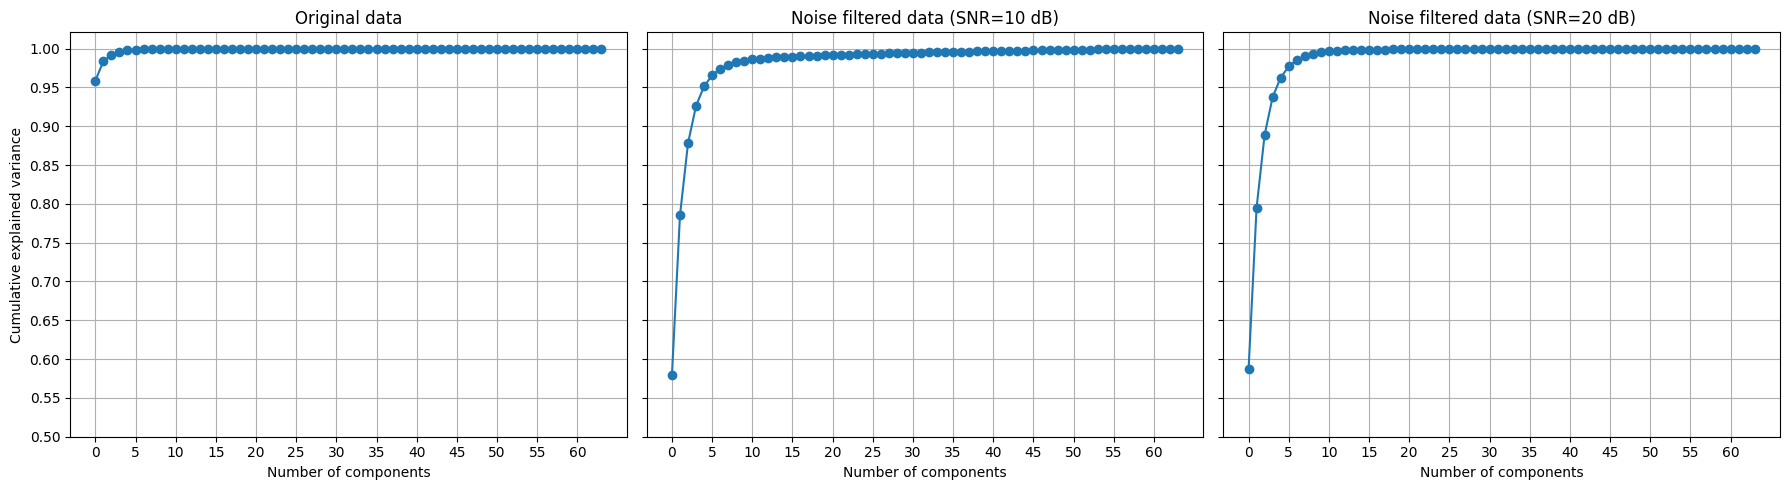

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Lista con tus datasets
datasets = {
    "Original data": X_train,
    "Noise filtered data (SNR=10 dB)": X_train_filt_10dB,
    "Noise filtered data (SNR=20 dB)": X_train_filt_20dB
}

# Configuración
np.random.seed(42)
thresholds = [0.95, 0.99]
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)  # 1 fila, 3 columnas

# Recorremos cada conjunto de datos
for i, (label, data) in enumerate(datasets.items()):
    num_models = len(X_train)
    total_models = data.shape[0]

    # Selección aleatoria de modelos
    random_indices = np.random.choice(total_models, size=num_models, replace=False)
    all_cum_var = []

    # PCA por modelo
    for idx in random_indices:
        model = data[idx]  # shape: (64, 1000)
        pca = PCA()
        pca.fit(model)
        cum_var = np.cumsum(pca.explained_variance_ratio_)
        all_cum_var.append(cum_var)

    all_cum_var = np.array(all_cum_var)
    mean_cum_var = np.mean(all_cum_var, axis=0)

    # Gráfico
    axes[i].plot(mean_cum_var, marker='o')
    axes[i].set_title(label)
    axes[i].set_xlabel('Number of components')
    axes[i].set_yticks(np.arange(0.5, 1.01, 0.05))
    axes[i].set_xticks(np.arange(0.0, 64, 5))
    if i == 0:
        axes[i].set_ylabel('Cumulative explained variance')
    axes[i].grid(True)

    # Calcular componentes para umbrales
    for t in thresholds:
        n_components = np.argmax(mean_cum_var >= t) + 1
        print(f"{label}: {t*100:.0f}% variance → {n_components} components")

plt.tight_layout()
plt.show()


In [10]:
# PRINCIPAL COMPONENT ANALYSIS (PCA)

from sklearn.decomposition import PCA

def apply_pca(X, n_components):
    # APLICAR PCA A CADA MODELO
    n_components = n_components
    X_pca = []
    for model in X:
        model_T = model.T  # Transponer para que las muestras sean filas
        pca = PCA(n_components=n_components)
        model_pca = pca.fit_transform(model_T)  # (1000, 2)

        # Si quieres devolverlo como (64, 2) puedes transponer de nuevo
        model_pca = model_pca.T  # (2, 1000)
        X_pca.append(model_pca)

    return np.array(X_pca)

#original_data
X_train_pca = apply_pca(X_train, n_components=4)
X_test_pca = apply_pca(X_test, n_components=4)

#filtered_data_10dB
X_train_filt_10dB_pca = apply_pca(X_train_filt_10dB, n_components=4)
X_test_filt_10dB_pca = apply_pca(X_test_filt_10dB, n_components=4)

#filtered_data_20dB
X_train_filt_20dB_pca = apply_pca(X_train_filt_20dB, n_components=4)
X_test_filt_20dB_pca = apply_pca(X_test_filt_20dB, n_components=4)


print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_pca[0].shape} (3 componentes x 500 muestras)")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_pca[0].shape} (3 componentes x 500 muestras)")
print(f"PCA aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_pca[0].shape} (3 componentes x 500 muestras)")
print(f"No PCA applied. Ejemplo dimensiones: {X_train[0].shape} (64 canales x 500 muestras)")

PCA aplicado por modelo. Ejemplo dimensiones: (4, 2000) (3 componentes x 500 muestras)
PCA aplicado por modelo. Ejemplo dimensiones: (4, 2000) (3 componentes x 500 muestras)
PCA aplicado por modelo. Ejemplo dimensiones: (4, 2000) (3 componentes x 500 muestras)
No PCA applied. Ejemplo dimensiones: (64, 2000) (64 canales x 500 muestras)


In [11]:
# WAVELET SCATTERING TRANSFORM

from kymatio import Scattering1D

def apply_wavelet_scattering(X, J=4, Q=(16, 16)):
    # APLICAR SCATTERING A CADA MODELO
    J = 4
    Q = (16,16)

    ws_coeffs = []  

    for model in X:
        model_coeffs = []  
        
        for j in range(len(model)):
            signal = np.array(model[j])  
            len_signal = len(signal)
            
            scattering = Scattering1D(J=J, shape=(len_signal,), Q=Q)
            Sx = scattering(signal)  
            model_coeffs.append(Sx)  
        ws_coeffs.append(np.stack(model_coeffs))
    return np.array(ws_coeffs)

#original_data
X_train_ws = apply_wavelet_scattering(X_train_pca)
X_test_ws = apply_wavelet_scattering(X_test_pca)

#filtered_data_10dB
X_train_filt_10dB_ws = apply_wavelet_scattering(X_train_filt_10dB_pca)
X_test_filt_10dB_ws = apply_wavelet_scattering(X_test_filt_10dB_pca)

#filtered_data_20dB
X_train_filt_20dB_ws = apply_wavelet_scattering(X_train_filt_20dB_pca)
X_test_filt_20dB_ws = apply_wavelet_scattering(X_test_filt_20dB_pca)

#original_data NO PCA
X_train_ws_no_pca = apply_wavelet_scattering(X_train)
X_test_ws_no_pca = apply_wavelet_scattering(X_test)

print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_10dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_filt_20dB_ws[0].shape} ")
print(f"Scattering aplicado por modelo. Ejemplo dimensiones: {X_train_ws_no_pca[0].shape} ")



Scattering aplicado por modelo. Ejemplo dimensiones: (4, 326, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (4, 326, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (4, 326, 125) 
Scattering aplicado por modelo. Ejemplo dimensiones: (64, 326, 125) 


-18.277946065696856 -2.939849501560256
31


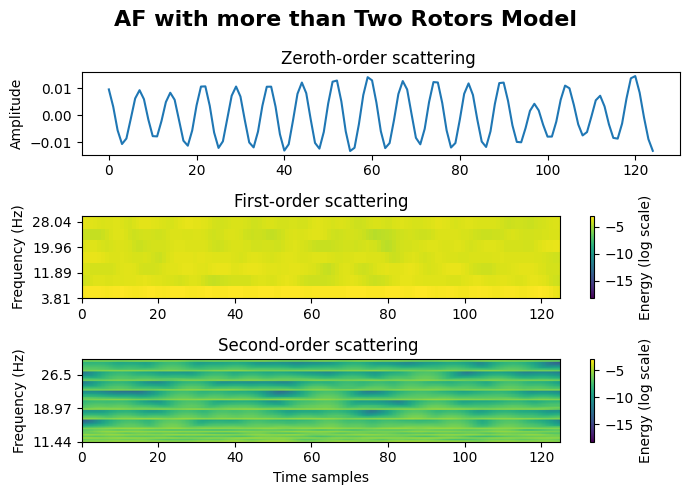

2
-21.98013098870236 -2.757001656607441
31


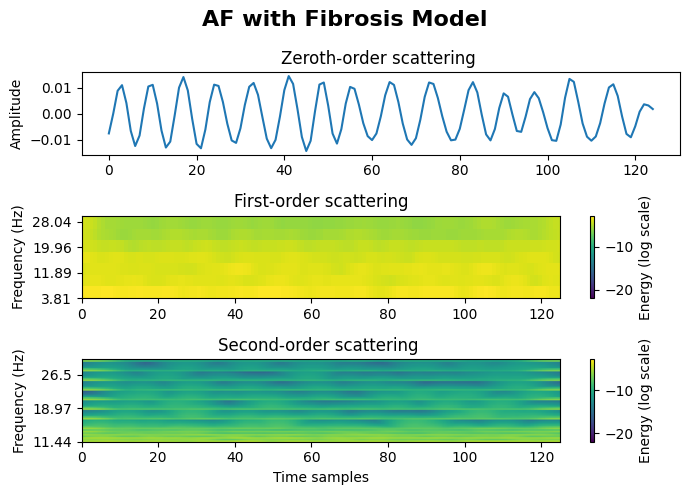

3
-18.01308270759169 -3.3273313924879013
31


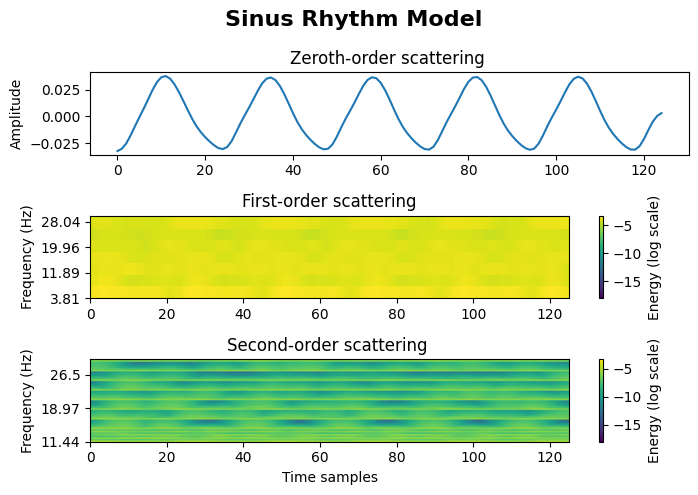

4
[2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 4, 4, 4, 4, 4, 4, 4, 4, 4, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2

In [14]:
# FUNCION QUE APLICA WAVELET SCATTERING PERO ME ENSEÑA LAS FRECUENCIAS EN HZ EN LOS EJES
from kymatio import Scattering1D
def wavelet_scattering(signal, J, Q, fs, type_name=''):
    T = len(signal)
    scattering = Scattering1D(J=J, shape=(T,), Q=Q)
    
    # Obtener coeficientes de scattering y metadatos
    Sx = scattering(signal)
    meta = scattering.meta()

    order_0 = np.where(meta['order'] == 0)[0]
    order_1 = np.where(meta['order'] == 1)[0]
    order_2 = np.where(meta['order'] == 2)[0]

    # Obtener frecuencias a partir de xi
    xi_order1 = meta['xi'][order_1, 0] * (fs / 2)
    xi_order2 = meta['xi'][order_2, 0] * (fs / 2)

    # Filtrar valores NaN
    xi_order1 = xi_order1[~np.isnan(xi_order1)]
    xi_order2 = xi_order2[~np.isnan(xi_order2)]

    # Redondear frecuencias para mejor visualización
    freq_order1 = np.round(xi_order1, 2)
    freq_order2 = np.round(xi_order2, 2)

    log_Sx1 = np.log10(Sx[order_1])
    log_Sx2 = np.log10(Sx[order_2])

    # Rango común para colorbars
    vmin = min(log_Sx1.min(), log_Sx2.min())
    vmax = max(log_Sx1.max(), log_Sx2.max())
    print(vmin, vmax)

    # Seleccionar solo algunas frecuencias para las etiquetas del eje Y
    num_ticks = 15 
    yticks_order1 = np.linspace(freq_order1[0], freq_order1[-1], num_ticks)
    yticks_order2 = np.linspace(freq_order2[0], freq_order2[-1], num_ticks)

    plt.figure(figsize=(7, 5))

    # Zeroth-order scattering
    plt.subplot(3, 1, 1)
    plt.plot(Sx[order_0][0])
    plt.title(f'Zeroth-order scattering ')
    plt.ylabel('Amplitude')
    
    # First-order scattering
    plt.subplot(3, 1, 2)
    plt.imshow(np.log10(Sx[order_1]), aspect='auto', extent=[0, len(Sx[order_1][0]), freq_order1[-1], freq_order1[0]], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'First-order scattering')
    plt.ylabel('Frequency (Hz)')
    plt.yticks(yticks_order1, np.round(yticks_order1, 2))  
    plt.ylim(freq_order1[-1],30) # LIMITO EL EJE A FRECUENCIAS MENORES DE 40 HZ PORQUE ES DONDE ESTÁN LAS FRECUENCIAS DE INTERÉS
    plt.colorbar(label='Energy (log scale)')
    print(len(freq_order1))

    # Second-order scattering
    plt.subplot(3, 1, 3)
    plt.imshow(np.log10(Sx[order_2]), aspect='auto', extent=[0, len(Sx[order_2][0]), freq_order2[-1], freq_order2[0]], vmin=vmin, vmax=vmax, cmap='viridis')
    plt.title(f'Second-order scattering ')
    plt.ylabel('Frequency (Hz)')
    plt.yticks(yticks_order2, np.round(yticks_order2, 2))  
    plt.ylim(freq_order2[-1],30)
    plt.colorbar(label='Energy (log scale)')

    plt.xlabel('Time samples')

    plt.suptitle(f'{type_name}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

fs = 500  # Ajusta según la frecuencia de tu señal
signal_2 = X_train_pca[30][0]  # Ejemplo de señal
wavelet_scattering(signal_2, J=4, Q=(16,16), fs=500, type_name='AF with more than Two Rotors Model')
print(y_train[30])



fs = 500  # Ajusta según la frecuencia de tu señal
signal_3 = X_train_pca[22][0]  # Ejemplo de señal
wavelet_scattering(signal_3, J=4, Q=(16,16), fs=500, type_name='AF with Fibrosis Model')
print(y_train[22])


fs = 500  # Ajusta según la frecuencia de tu señal
signal_4 = X_train_pca[82][0]  # Ejemplo de señal
wavelet_scattering(signal_4, J=4, Q=(16,16), fs=500, type_name='Sinus Rhythm Model')
print(y_train[82])



print(y_train)

In [15]:
X_train_final = X_train_ws.reshape(X_train_ws.shape[0], -1)
X_test_final = X_test_ws.reshape(X_test_ws.shape[0], -1)

X_train_filt_10dB_final = X_train_filt_10dB_ws.reshape(X_train_filt_10dB_ws.shape[0], -1)
X_test_filt_10dB_final = X_test_filt_10dB_ws.reshape(X_test_filt_10dB_ws.shape[0], -1)

X_train_filt_20dB_final = X_train_filt_20dB_ws.reshape(X_train_filt_20dB_ws.shape[0], -1)
X_test_filt_20dB_final = X_test_filt_20dB_ws.reshape(X_test_filt_20dB_ws.shape[0], -1)

X_train_no_pca_final = X_train_ws_no_pca.reshape(X_train_ws_no_pca.shape[0], -1)
X_test_no_pca_final = X_test_ws_no_pca.reshape(X_test_ws_no_pca.shape[0], -1)

print(f"Datos finales: {X_train_final.shape}, {X_test_final.shape}")
print(f"Datos finales filtrados 10dB: {X_train_filt_10dB_final.shape}, {X_test_filt_10dB_final.shape}")
print(f"Datos finales filtrados 20dB: {X_train_filt_20dB_final.shape}, {X_test_filt_20dB_final.shape}")
print(f"Datos finales sin PCA: {X_train_no_pca_final.shape}, {X_test_no_pca_final.shape}")

Datos finales: (560, 163000), (250, 163000)
Datos finales filtrados 10dB: (560, 163000), (250, 163000)
Datos finales filtrados 20dB: (560, 163000), (250, 163000)
Datos finales sin PCA: (560, 2608000), (250, 2608000)


In [16]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score, precision_score
def random_forest_100(X_train_final, y_train, X_test_final, y_test):
    # Entrenar el modelo Random Forest
    rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=None, bootstrap=True, random_state=42, n_jobs=-1)
    rf.fit(X_train_final, y_train)

    # Predecir clases
    y_pred = rf.predict(X_test_final)

    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Obtener probabilidades predichas (necesarias para AUC multiclase y log loss)
    y_proba = rf.predict_proba(X_test_final)  # shape (n_samples, n_classes)

    # AUC ROC multiclase requiere que las etiquetas estén binarizadas (one-hot)
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)

    # Calcular AUC-ROC multiclase (One-vs-Rest)
    auc_roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
    print("AUC-ROC (multiclase OVR):", auc_roc)

    # Calcular Log Loss
    loss = log_loss(y_test_bin, y_proba)
    print("Log loss:", loss)
    return rf

rf_original = random_forest_100(X_train_final, y_train, X_test_final, y_test)
rf_filtered_10dB = random_forest_100(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test)
rf_filtered_20dB = random_forest_100(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test)
rf_no_pca = random_forest_100(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test)


Classification Report:
               precision    recall  f1-score   support

           2       1.00      0.95      0.97       190
           3       0.67      1.00      0.80        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.89      0.98      0.92       250
weighted avg       0.97      0.96      0.96       250

Confusion Matrix:
 [[180  10   0]
 [  0  20   0]
 [  0   0  40]]
AUC-ROC (multiclase OVR): 0.9776411136536994
Log loss: 0.13837153331609564
Classification Report:
               precision    recall  f1-score   support

           2       1.00      1.00      1.00       190
           3       1.00      1.00      1.00        20
           4       1.00      1.00      1.00        40

    accuracy                           1.00       250
   macro avg       1.00      1.00      1.00       250
weighted avg       1.00      1.00      1.00       250

Confusion Matrix:
 [[190   0   0]
 [  0  20   0]
 

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint
# Distribución de búsqueda
def tunning_random_forest(X_train_final, y_train, rf):
    # Crear el modelo Random Forest
    param_dist = {
    'max_depth': [None] + list(range(10, 50, 10)),
    'min_samples_split': randint(2, 11),
    'min_samples_leaf': randint(1, 5),
    'max_features': ['sqrt', 'log2', None]
}
    random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_dist,
                                   n_iter=50, cv=5, random_state=42,
                                   n_jobs=-1, verbose=2, scoring='accuracy')

    
    random_search.fit(X_train_final, y_train)
    best_model = random_search.best_estimator_
    print("Mejores hiperparámetros:", random_search.best_params_)
    
#tunning_random_forest(X_train_final, y_train, rf_original)
#tunning_random_forest(X_train_filt_10dB_final, y_train, rf_filtered_10dB)
#tunning_random_forest(X_train_filt_20dB_final, y_train, rf_filtered_20dB)
#tunning_random_forest(X_train_no_pca_final, y_train, rf_no_pca)


Fitting 5 folds for each of 50 candidates, totalling 250 fits


: 

In [ ]:
# RANDOM FOREST CLASSIFIER
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score, log_loss, f1_score
from sklearn.preprocessing import label_binarize
from sklearn.metrics import recall_score, precision_score
def apply_random_forest(X_train_final, y_train, X_test_final, y_test, max_depth, max_features, min_samples_split, min_samples_leaf, bootstrap):
    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt
    rf = RandomForestClassifier(class_weight='balanced', n_estimators=250, max_depth=max_depth, random_state=42, 
                            max_features=max_features, min_samples_split=min_samples_split, min_samples_leaf=min_samples_leaf, bootstrap=bootstrap, n_jobs=-1)

    rf.fit(X_train_final, y_train)

    # Predecir y evaluar en test
    y_pred = rf.predict(X_test_final)

    cm = confusion_matrix(y_test, y_pred)

    sensitivity = recall_score(y_test, y_pred, average='macro')  # o 'weighted'
    specificity = precision_score(y_test, y_pred, average='macro')  # Approximation

    acc = accuracy_score(y_test, y_pred)
    y_proba = rf.predict_proba(X_test_final)
    
    classes = np.unique(y_test)
    y_test_bin = label_binarize(y_test, classes=classes)
    auc_roc = roc_auc_score(y_test_bin, y_proba, multi_class='ovr')
    log_loss_value = log_loss(y_test, y_proba)
    f1_score_value = f1_score(y_test, rf.predict(X_test_final), average='weighted')

    print(classification_report(y_test, y_pred))
    print("Accuracy:", acc)
    print("Confusion Matrix:\n", cm)
    print("Sensitivity (Recall):", sensitivity)
    print("Specificity:", specificity)
    print("AUC-ROC:", auc_roc)
    print("Log loss:", log_loss_value)

    from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
    import matplotlib.pyplot as plt



    #disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    #disp.plot(cmap=plt.cm.Blues)  # Puedes cambiar el color si quieres
    #plt.title("Confusion Matrix")
    #plt.show()


    return acc, cm, sensitivity, specificity, y_proba, auc_roc, log_loss_value, f1_score_value


: 

In [ ]:
# Original_data

# Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 40, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 4}
# Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc, cm, sensitivity, specificity, y_proba, roc_auc, log_loss_, f1_score_ = apply_random_forest(X_train_final, y_train, X_test_final, y_test, max_depth=40, max_features=None, min_samples_split=4, min_samples_leaf=2, bootstrap=True)

              precision    recall  f1-score   support

           2       1.00      0.95      0.97       190
           3       0.67      1.00      0.80        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.89      0.98      0.92       250
weighted avg       0.97      0.96      0.96       250

Accuracy: 0.96
Confusion Matrix:
 [[180  10   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9824561403508771
Specificity: 0.8888888888888888
AUC-ROC: 0.9743376557335367
Log loss: 0.20753720892880315


In [ ]:
# filtered_data_10dB

# Mejores hiperparámetros: {'bootstrap': True, 'max_depth': 40, 'max_features': 'log2', 'min_samples_leaf': 3, 'min_samples_split': 6}
# Mejores hiperparámetros: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 8}
acc_filt_10dB, cm_filt_10dB, sensitivity_filt_10dB, specificity_filt_10dB, y_proba_filt_10dB, roc_auc_filt_10dB, log_loss_filt_10dB, f1_score_filt_10dB = apply_random_forest(X_train_filt_10dB_final, y_train, X_test_filt_10dB_final, y_test, max_depth=40, max_features='log2', min_samples_split=6, min_samples_leaf=3, bootstrap=True)


              precision    recall  f1-score   support

           2       1.00      0.99      1.00       190
           3       0.95      1.00      0.98        20
           4       1.00      1.00      1.00        40

    accuracy                           1.00       250
   macro avg       0.98      1.00      0.99       250
weighted avg       1.00      1.00      1.00       250

Accuracy: 0.996
Confusion Matrix:
 [[189   1   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9982456140350878
Specificity: 0.9841269841269842
AUC-ROC: 0.9999707602339182
Log loss: 0.19932081390423378


In [ ]:
# filtered_data_20dB

# Mejores hiperparámetros: {'bootstrap': False, 'max_depth': 40, 'max_features': None, 'min_samples_leaf': 3, 'min_samples_split': 2}
#Mejores hiperparámetros: {'max_depth': 30, 'max_features': 'sqrt', 'min_samples_leaf': 3, 'min_samples_split': 9}
acc_filt_20dB, cm_filt_20dB, sensitivity_filt_20dB, specificity_filt_20dB, y_proba_filt_20dB, roc_auc_filt_20dB, log_loss_filt_20dB, f1_score_filt_20dB = apply_random_forest(X_train_filt_20dB_final, y_train, X_test_filt_20dB_final, y_test, max_depth=40, max_features=None, min_samples_split=2, min_samples_leaf=3, bootstrap=True)


              precision    recall  f1-score   support

           2       1.00      0.95      0.98       190
           3       0.69      1.00      0.82        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.90      0.98      0.93       250
weighted avg       0.98      0.96      0.97       250

Accuracy: 0.964
Confusion Matrix:
 [[181   9   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9842105263157895
Specificity: 0.896551724137931
AUC-ROC: 0.9870582252733282
Log loss: 0.24273707135817368


In [ ]:
# no PCA

# Mejores hiperparámetros: {'bootstrap': False, 'max_depth': 20, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3}
acc_no_pca, cm_no_pca, sensitivity_no_pca, specificity_no_pca, y_proba_no_pca, roc_auc_no_pca, log_loss_no_pca, f1_score_no_pca = apply_random_forest(X_train_no_pca_final, y_train, X_test_no_pca_final, y_test, max_depth=20, max_features='log2', min_samples_split=3, min_samples_leaf=1, bootstrap=True)

              precision    recall  f1-score   support

           2       1.00      0.95      0.97       190
           3       0.67      1.00      0.80        20
           4       1.00      1.00      1.00        40

    accuracy                           0.96       250
   macro avg       0.89      0.98      0.92       250
weighted avg       0.97      0.96      0.96       250

Accuracy: 0.96
Confusion Matrix:
 [[180  10   0]
 [  0  20   0]
 [  0   0  40]]
Sensitivity (Recall): 0.9824561403508771
Specificity: 0.8888888888888888
AUC-ROC: 0.9996802695143656
Log loss: 0.08801999183801872


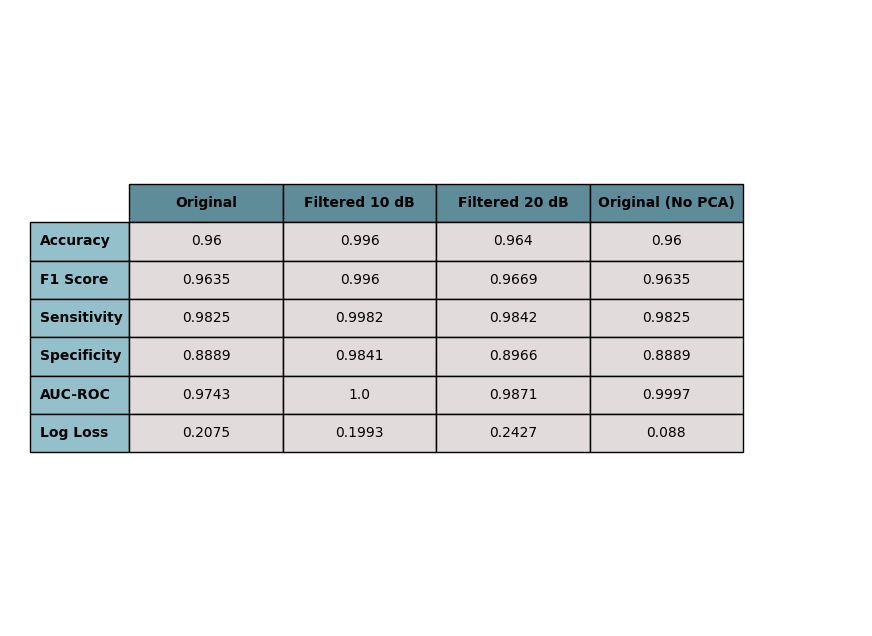

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Datos de ejemplo (rellena con tus variables reales)
metrics_dict = {
    'Original': {
        'Accuracy': acc,
        'F1 Score': f1_score_,
        'Sensitivity': sensitivity,
        'Specificity': specificity,
        'AUC-ROC': roc_auc,
        'Log Loss': log_loss_,
    },
    'Filtered 10 dB': {
        'Accuracy': acc_filt_10dB,
        'F1 Score': f1_score_filt_10dB,
        'Sensitivity': sensitivity_filt_10dB,
        'Specificity': specificity_filt_10dB,
        'AUC-ROC': roc_auc_filt_10dB,
        'Log Loss': log_loss_filt_10dB,
    },
    'Filtered 20 dB': {
        'Accuracy': acc_filt_20dB,
        'F1 Score': f1_score_filt_20dB,
        'Sensitivity': sensitivity_filt_20dB,
        'Specificity': specificity_filt_20dB,
        'AUC-ROC': roc_auc_filt_20dB,
        'Log Loss': log_loss_filt_20dB,
    },
    'Original (No PCA)': {
        'Accuracy': acc_no_pca,
        'F1 Score': f1_score_no_pca,
        'Sensitivity': sensitivity_no_pca,
        'Specificity': specificity_no_pca,
        'AUC-ROC': roc_auc_no_pca,
        'Log Loss': log_loss_no_pca,
    },
}

import pandas as pd
import matplotlib.pyplot as plt
from pandas.plotting import table

# Crear el DataFrame y redondear
df_metrics = pd.DataFrame(metrics_dict).round(4)

# Crear figura y tabla
fig, ax = plt.subplots(figsize=(11, 8))
ax.axis('off')
tbl = table(ax, df_metrics, loc='center', cellLoc='center', colWidths=[0.15]*df_metrics.shape[1])

# Estética general
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 2.3)

# Aplicar estilo a encabezados
for (row, col), cell in tbl.get_celld().items():
    if row == 0:  # encabezados
        cell.set_text_props(weight='bold', color='black')
        cell.set_facecolor("#5f8c99")  # gris claro
    elif col == -1:  # fila de índices (las métricas)
        cell.set_text_props(weight='bold')
        cell.set_facecolor("#93c0cb")

    else:
        cell.set_facecolor("#dbd2d2cc")

# Guardar imagen
plt.savefig("styled_metrics_table.png", bbox_inches='tight', dpi=300)
plt.show()
